# Домашня робота №7

# Перетворення випадкових величин та векторів

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## 1 Нормальний розподіл

### 1.1 Завдання 1.1

Розглянемо три незалежні випадкові величини $\xi_1, \xi_2, \theta$ такі,
що $\xi_1, \xi_2 \sim N(0, 1), \theta \sim Uniform(0, 2 \pi)$.

Який розподіл має випадкова величина $\displaystyle \zeta = \xi_1 \cos \theta + \xi_2 \sin \theta$?
1. Згенеруйте $n = 10000$ значень випадкових величин $\xi_1, \xi_2, \theta$;
2. Отримайте $n = 10000$ значень випадкової величини $\zeta$;
3. Зобразіть на графіку:
   - нормовану гістограму отриманих $n = 10000$ значень випадкової величини $\zeta$;
   - функцію щільності випадкової величини $\zeta$.

**Зауваження.** Передбачається використання теореми про лінійне перетворення нормальних величин.

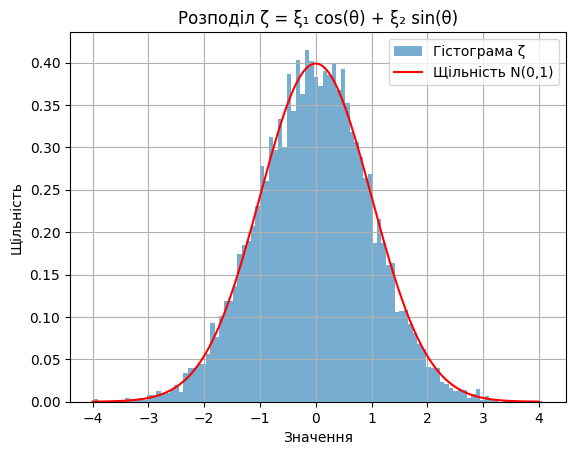

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

n = 10000
xi1 = np.random.normal(0, 1, n)
xi2 = np.random.normal(0, 1, n)
theta = np.random.uniform(0, 2 * np.pi, n)

zeta = xi1 * np.cos(theta) + xi2 * np.sin(theta)

x = np.linspace(-4, 4, 1000)
pdf = norm.pdf(x, loc=0, scale=1)

plt.hist(zeta, bins=100, density=True, alpha=0.6, label="Гістограма ζ")
plt.plot(x, pdf, 'r-', label="Щільність N(0,1)")
plt.title("Розподіл ζ = ξ₁ cos(θ) + ξ₂ sin(θ)")
plt.xlabel("Значення")
plt.ylabel("Щільність")
plt.legend()
plt.grid(True)
plt.show()

### 1.1 Завдання 1.2

Розглянемо дві незалежні випадкові величини $\xi_1, \xi_2$ зі стандартного нормального розподілу.
Тобто $\xi_1, \xi_2 \sim N(0, 1)$.

Які розподіли (щільності) мають випадкові величини $\displaystyle \zeta = \sqrt{\xi_1^2 + \xi_2^2}, \eta = \arccos \frac{\xi_1}{\zeta}$?
1. Згенеруйте $n = 10000$ значень випадкових величин $\xi_1, \xi_2$;
2. Отримайте $n = 10000$ значень випадкової величини $\zeta$;
3. Отримайте $n = 10000$ значень випадкової величини $\eta$;
4. Зобразіть на графіку:
   - нормовану гістограму отриманих $n = 10000$ значень випадкової величини $\zeta$;
   - функцію щільності випадкової величини $\zeta$;
5. Зобразіть на графіку:
   - нормовану гістограму отриманих $n = 10000$ значень випадкової величини $\eta$;
   - функцію щільності випадкової величини $\eta$.

**Зауваження 1.** Передбачається використання теореми про обрахунок щільності функції від випадкової величини (через якобіан оберненого відображення).

**Зауваження 2.** Насправді, розподіл отриманих значень випадкової величини $\eta$ буде трохи відрізнятися від порахованого теоретично (будуть інші параметри).
Так виходить за рахунок реалізації функції $\arccos$ (її області значень).

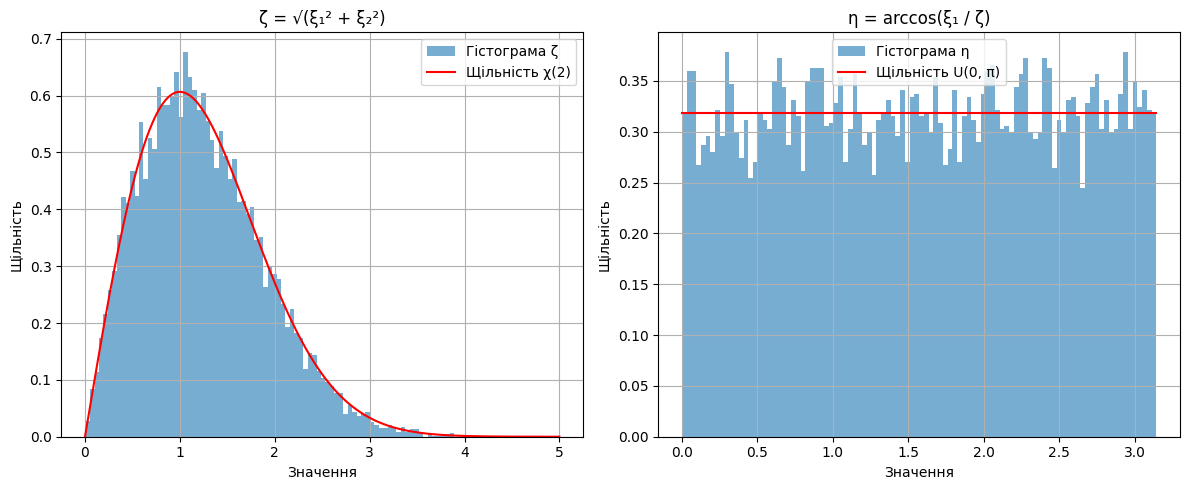

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi, uniform

n = 10000
xi1 = np.random.normal(0, 1, n)
xi2 = np.random.normal(0, 1, n)

zeta = np.sqrt(xi1**2 + xi2**2)
eta = np.arccos(xi1 / zeta)

x_zeta = np.linspace(0, 5, 1000)
f_zeta = chi.pdf(x_zeta, df=2)

x_eta = np.linspace(0, np.pi, 1000)
f_eta = uniform.pdf(x_eta, loc=0, scale=np.pi)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].hist(zeta, bins=100, density=True, alpha=0.6, label="Гістограма ζ")
axs[0].plot(x_zeta, f_zeta, 'r-', label="Щільність χ(2)")
axs[0].set_title("ζ = √(ξ₁² + ξ₂²)")
axs[0].set_xlabel("Значення")
axs[0].set_ylabel("Щільність")
axs[0].legend()
axs[0].grid(True)

axs[1].hist(eta, bins=100, density=True, alpha=0.6, label="Гістограма η")
axs[1].plot(x_eta, f_eta, 'r-', label="Щільність U(0, π)")
axs[1].set_title("η = arccos(ξ₁ / ζ)")
axs[1].set_xlabel("Значення")
axs[1].set_ylabel("Щільність")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()